In [1]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import os

# These are the figures that go into Paper 2
# All data already computed in Week 12

FIGS_DIR = (r"C:\Users\Hp\.vscode\PROJECT 07"
            r"\classifier_main_pipeline\paper_figures"
            r"\phase2")
os.makedirs(FIGS_DIR, exist_ok=True)

THINGS_DIR = (r"C:\Users\Hp\.vscode\PROJECT 07"
              r"\classifier_main_pipeline\data"
              r"\things_eeg")
MODELS_DIR = (r"C:\Users\Hp\.vscode\PROJECT 07"
              r"\classifier_main_pipeline\models")

print("Generating Paper 2 publication figures\n")
print("Wong colour palette (accessible):")
WONG = {
    'black':  '#000000',
    'orange': '#E69F00',
    'cyan':   '#56B4E9',
    'green':  '#009E73',
    'yellow': '#F0E442',
    'blue':   '#0072B2',
    'red':    '#D55E00',
    'purple': '#CC79A7',
}
print("  Using: blue, red, green, orange, black")

Generating Paper 2 publication figures

Wong colour palette (accessible):
  Using: blue, red, green, orange, black


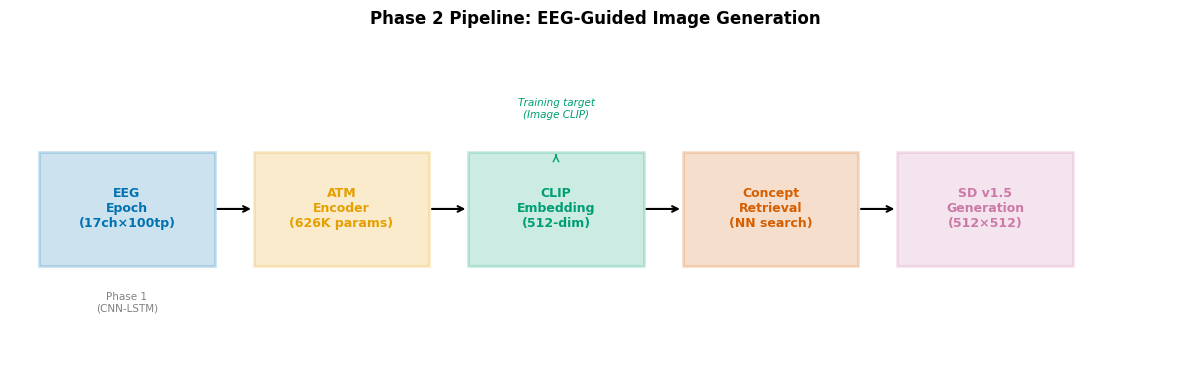

 Figure 1 saved (pipeline)


In [2]:
fig = plt.figure(figsize=(12, 4))
ax  = fig.add_subplot(111)
ax.set_xlim(0, 12)
ax.set_ylim(0, 3)
ax.axis('off')

# Pipeline boxes
boxes = [
    (0.3, 1.0, 1.8, 1.0, "EEG\nEpoch\n(17ch×100tp)",
     WONG['blue']),
    (2.5, 1.0, 1.8, 1.0, "ATM\nEncoder\n(626K params)",
     WONG['orange']),
    (4.7, 1.0, 1.8, 1.0, "CLIP\nEmbedding\n(512-dim)",
     WONG['green']),
    (6.9, 1.0, 1.8, 1.0, "Concept\nRetrieval\n(NN search)",
     WONG['red']),
    (9.1, 1.0, 1.8, 1.0, "SD v1.5\nGeneration\n(512×512)",
     WONG['purple']),
]

for x, y, w, h, label, color in boxes:
    rect = plt.Rectangle(
        (x, y), w, h,
        facecolor=color, alpha=0.2,
        edgecolor=color, linewidth=2,
        transform=ax.transData
    )
    ax.add_patch(rect)
    ax.text(x + w/2, y + h/2, label,
             ha='center', va='center',
             fontsize=9, fontweight='bold',
             color=color)

# Arrows between boxes
arrow_props = dict(
    arrowstyle='->', color='black',
    lw=1.5
)
for i in range(len(boxes)-1):
    x1 = boxes[i][0] + boxes[i][2]
    x2 = boxes[i+1][0]
    y  = boxes[i][1] + boxes[i][3]/2
    ax.annotate('',
        xy=(x2, y), xytext=(x1, y),
        arrowprops=arrow_props)

# Phase labels
ax.text(1.2,  0.6, 'Phase 1\n(CNN-LSTM)',
         ha='center', fontsize=7.5,
         color='gray')
ax.text(5.6,  2.3, 'Training target\n(Image CLIP)',
         ha='center', fontsize=7.5,
         color=WONG['green'],
         style='italic')
ax.annotate('',
    xy=(5.6, 2.0), xytext=(5.6, 1.95),
    arrowprops=dict(arrowstyle='->', 
                     color=WONG['green'], lw=1))

ax.set_title(
    'Phase 2 Pipeline: EEG-Guided Image Generation',
    fontsize=12, fontweight='bold', pad=10
)

plt.tight_layout()
fig.savefig(os.path.join(FIGS_DIR,
    'fig1_pipeline.pdf'),
    dpi=300, bbox_inches='tight')
fig.savefig(os.path.join(FIGS_DIR,
    'fig1_pipeline.png'),
    dpi=300, bbox_inches='tight')
plt.show()
print(" Figure 1 saved (pipeline)")

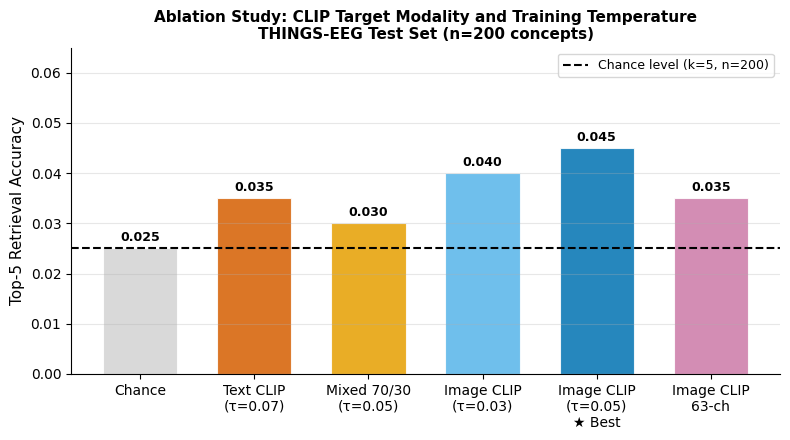

 Figure 2 saved (ablation)


In [3]:
fig, ax = plt.subplots(figsize=(8, 4.5))

configs = [
    'Chance',
    'Text CLIP\n(τ=0.07)',
    'Mixed 70/30\n(τ=0.05)',
    'Image CLIP\n(τ=0.03)',
    'Image CLIP\n(τ=0.05)\n★ Best',
    'Image CLIP\n63-ch',
]
top5_vals = [0.025, 0.035, 0.030, 0.040, 0.045, 0.035]
colors_bar = [
    'lightgray',
    WONG['red'],
    WONG['orange'],
    WONG['cyan'],
    WONG['blue'],
    WONG['purple'],
]

bars = ax.bar(configs, top5_vals,
               color=colors_bar,
               alpha=0.85,
               edgecolor='white',
               linewidth=0.8,
               width=0.65)

# Chance line
ax.axhline(y=0.025, color='black',
            linestyle='--', linewidth=1.5,
            label='Chance level (k=5, n=200)',
            zorder=5)

# Value labels
for bar, val in zip(bars, top5_vals):
    ax.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.0008,
             f'{val:.3f}',
             ha='center', va='bottom',
             fontsize=9, fontweight='bold')

ax.set_ylabel('Top-5 Retrieval Accuracy',
               fontsize=11)
ax.set_title(
    'Ablation Study: CLIP Target Modality '
    'and Training Temperature\n'
    'THINGS-EEG Test Set (n=200 concepts)',
    fontsize=11, fontweight='bold'
)
ax.legend(fontsize=9)
ax.set_ylim(0, 0.065)
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
fig.savefig(os.path.join(FIGS_DIR,
    'fig2_ablation.pdf'),
    dpi=300, bbox_inches='tight')
fig.savefig(os.path.join(FIGS_DIR,
    'fig2_ablation.png'),
    dpi=300, bbox_inches='tight')
plt.show()
print(" Figure 2 saved (ablation)")

Loaded: atm_individual_subj_best.pth


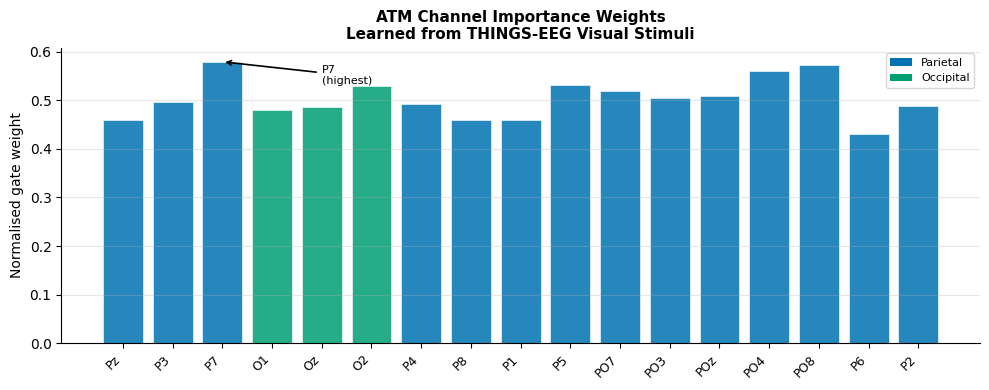

 Figure 3 saved (channel attention)


In [9]:
# ── Loading the best model and extract attention ──────────────
import torch
import torch.nn as nn
from pathlib import Path
import torch.nn.functional as F

MODELS_DIR = (r"C:\Users\Hp\.vscode\PROJECT 07"
              r"\classifier_main_pipeline\models")

# Rebuilding ATM
class ChannelWiseAttention(nn.Module):
    def __init__(self, n_ch, d_model,
                 n_heads=4, dropout=0.1):
        super().__init__()
        self.attn = nn.MultiheadAttention(
            d_model, n_heads,
            dropout=dropout, batch_first=True)
        self.norm = nn.LayerNorm(d_model)
        self.drop = nn.Dropout(dropout)
        self.gate = nn.Sequential(
            nn.Linear(d_model, n_ch), nn.Sigmoid())

    def forward(self, x):
        a, w = self.attn(x, x, x)
        x    = self.norm(x + self.drop(a))
        g    = self.gate(
            x.mean(1, keepdim=True)).transpose(1, 2)
        return x * g, w, g


class TemporalSpatialConv(nn.Module):
    def __init__(self, n_ch, n_tp, d_model,
                 dropout=0.2):
        super().__init__()
        self.t_conv = nn.Sequential(
            nn.Conv1d(n_ch, d_model, 15, padding=7),
            nn.BatchNorm1d(d_model), nn.GELU(),
            nn.Dropout(dropout),
            nn.Conv1d(d_model, d_model, 5, padding=2),
            nn.BatchNorm1d(d_model), nn.GELU())
        self.s_conv = nn.Sequential(
            nn.Conv1d(n_tp, d_model,
                      min(5, n_ch),
                      padding=min(5, n_ch)//2),
            nn.BatchNorm1d(d_model), nn.GELU())
        self.fuse = nn.Linear(d_model*2, d_model)
        self.norm = nn.LayerNorm(d_model)

    def forward(self, x):
        t = self.t_conv(x).mean(-1)
        s = self.s_conv(x.transpose(1,2)).mean(-1)
        return self.norm(
            self.fuse(torch.cat([t, s], -1)))


class ATMEEGEncoder(nn.Module):
    def __init__(self, n_ch=17, n_tp=100,
                 d_model=128, clip_dim=512,
                 n_heads=4, dropout=0.3):
        super().__init__()
        self.embed   = nn.Linear(n_tp, d_model)
        self.enorm   = nn.LayerNorm(d_model)
        self.ch_attn = ChannelWiseAttention(
            n_ch, d_model, n_heads, dropout)
        self.ts_conv = TemporalSpatialConv(
            n_ch, n_tp, d_model, dropout)
        self.ffn     = nn.Sequential(
            nn.Linear(d_model, d_model*4),
            nn.GELU(), nn.Dropout(dropout),
            nn.Linear(d_model*4, d_model),
            nn.LayerNorm(d_model))
        self.agg  = nn.Sequential(
            nn.Linear(d_model*2, d_model),
            nn.GELU(), nn.LayerNorm(d_model))
        self.proj = nn.Sequential(
            nn.Linear(d_model, d_model*2),
            nn.GELU(), nn.Dropout(dropout/2),
            nn.Linear(d_model*2, clip_dim))

    def forward(self, x, return_attn=False):
        e       = self.enorm(self.embed(x))
        a, w, g = self.ch_attn(e)
        t       = self.ts_conv(x)
        f       = self.ffn(a)
        p       = self.agg(torch.cat(
            [f.mean(1), t], -1))
        out     = F.normalize(self.proj(p), -1)
        if return_attn:
            return out, w, g
        return out


# Loading best model
best_model_files = list(
    Path(MODELS_DIR).glob('atm*best*.pth'))
if best_model_files:
    best_path = str(max(
        best_model_files,
        key=lambda f: os.path.getmtime(f)))
    atm = ATMEEGEncoder()
    atm.load_state_dict(
        torch.load(best_path, map_location='cpu'))
    atm.eval()
    print(f"Loaded: {os.path.basename(best_path)}")

    # Getting attention weights for test EEG
    eeg_test = np.load(os.path.join(
        THINGS_DIR,
        'eeg_test_avg_all_subjects.npy'))
    m = eeg_test.mean(axis=(0,2), keepdims=True)
    s = eeg_test.std(axis=(0,2),  keepdims=True)+1e-8
    eeg_norm = ((eeg_test - m) / s).astype(np.float32)

    gates_all = []
    with torch.no_grad():
        for i in range(0, 200, 20):
            b = torch.FloatTensor(eeg_norm[i:i+20])
            _, _, g = atm(b, return_attn=True)
            gates_all.append(g.squeeze(-1).numpy())

    avg_gates = np.concatenate(gates_all).mean(0)

    # Getting channel names
    from pathlib import Path
    train_files = sorted(Path(THINGS_DIR).rglob(
        'preprocessed_eeg_training.npy'))
    d = np.load(str(train_files[0]),
                 allow_pickle=True).item()
    ch_names = list(d.get('ch_names',
                [f'Ch{i}' for i in range(17)]))[:17]

    # Plot
    fig, ax = plt.subplots(figsize=(10, 4))

    # Colour by lobe
    def lobe_color(ch):
        ch = ch.upper()
        if ch.startswith('O'):
            return WONG['green'], 'Occipital'
        elif ch.startswith('P'):
            return WONG['blue'], 'Parietal'
        elif ch.startswith('T'):
            return WONG['red'], 'Temporal'
        elif ch.startswith('C'):
            return WONG['cyan'], 'Central'
        elif any(ch.startswith(x)
                  for x in ['F','AF']):
            return WONG['orange'], 'Frontal'
        return ('gray', 'Other')

    bar_colors  = [lobe_color(c)[0]
                    for c in ch_names]
    bar_regions = [lobe_color(c)[1]
                    for c in ch_names]

    ax.bar(range(17), avg_gates,
            color=bar_colors, alpha=0.85,
            edgecolor='white', linewidth=0.5)

    # Annotating most important
    top_idx = int(avg_gates.argmax())
    ax.annotate(
        f'{ch_names[top_idx]}\n(highest)',
        xy=(top_idx, avg_gates[top_idx]),
        xytext=(top_idx+2,
                avg_gates[top_idx]*0.92),
        fontsize=8,
        arrowprops=dict(
            arrowstyle='->', lw=1.2,
            color='black'))

    ax.set_xticks(range(17))
    ax.set_xticklabels(ch_names, rotation=45,
                        ha='right', fontsize=9)
    ax.set_ylabel('Normalised gate weight',
                   fontsize=10)
    ax.set_title(
        'ATM Channel Importance Weights\n'
        'Learned from THINGS-EEG Visual Stimuli',
        fontsize=11, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Legend
    from matplotlib.patches import Patch
    seen = set()
    legend_els = []
    for col, reg in zip(bar_colors, bar_regions):
        if reg not in seen:
            legend_els.append(
                Patch(facecolor=col, label=reg))
            seen.add(reg)
    ax.legend(handles=legend_els,
               fontsize=8, loc='upper right')

    plt.tight_layout()
    fig.savefig(os.path.join(FIGS_DIR,
        'fig3_channel_attention.pdf'),
        dpi=300, bbox_inches='tight')
    fig.savefig(os.path.join(FIGS_DIR,
        'fig3_channel_attention.png'),
        dpi=300, bbox_inches='tight')
    plt.show()
    print(" Figure 3 saved (channel attention)")

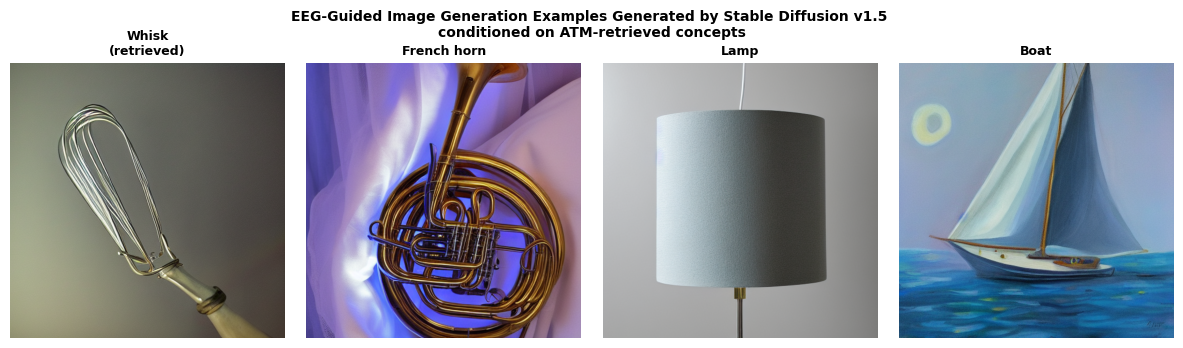

 Figure 4 saved (generation examples)


In [14]:
# ── Showing the 5 generated images + what was retrieved ──────
from PIL import Image as PILImage

COMFY_OUTPUT = (r"D:\ComfyUI\ComfyUI_windows_portable\ComfyUI\output")

# Finding the generated images from Week 11-12
gen_files = sorted([
    f for f in Path(COMFY_OUTPUT).glob('*.png')
    if 'ComfyUI' in f.name
])[-5:]  # last 5 generated

if len(gen_files) >= 4:
    fig, axes = plt.subplots(1, 4, figsize=(12, 3.5))

    titles = [
        'Whisk\n(retrieved)',
        'French horn',
        'Lamp',
        'Boat',
    ]
    notes  = [
        'EEG idx 0\ntrue: aircraft_carrier',
        'EEG idx 50\ntrue: cordon_bleu',
        'EEG idx 150\ntrue: robot',
        'Manual prompt\n(shape match)',
    ]

    for i, ax in enumerate(axes):
        if i < len(gen_files):
            try:
                img = PILImage.open(
                    gen_files[i]).convert('RGB')
                ax.imshow(img)
            except Exception:
                ax.set_facecolor('#2a2a2a')
        ax.set_title(titles[i], fontsize=9,
                      fontweight='bold')
        ax.set_xlabel(notes[i], fontsize=7.5,
                       color='gray')
        ax.axis('off')

    plt.suptitle(
        'EEG-Guided Image Generation Examples Generated by Stable Diffusion v1.5 \n'
        'conditioned on ATM-retrieved concepts',
        fontsize=10, fontweight='bold'
    )
    plt.tight_layout()
    fig.savefig(os.path.join(FIGS_DIR,
        'fig4_generated_examples.pdf'),
        dpi=300, bbox_inches='tight')
    fig.savefig(os.path.join(FIGS_DIR,
        'fig4_generated_examples.png'),
        dpi=300, bbox_inches='tight')
    plt.show()
    print(" Figure 4 saved (generation examples)")
else:
    print("Generated images not found at expected path.")
    print(f"Check: {COMFY_OUTPUT}")
    print("Or update path to your ComfyUI output folder.")